# 03 — Hasil Test Comparison (Analisis Perbandingan)

Notebook ini **memuat hasil metrik** yang telah dijalankan dan disimpan oleh notebook `02.1`, `02.2`, `02.3`, `02.4`, dan QLDE (jika skrip save QLDE sudah dijalankan).  

**Algoritma yang dibandingkan:**
1. **K-means-QLDE** (Proposed Algorithm)
2. **Standard K-means** (Baseline)
3. **K-means-DE** (F Konstan)
4. **K-means-PSO** (Particle Swarm Optimization)
5. **K-means-EOA** (Equilibrium Optimizer Algorithm)

**Metrik yang dibandingkan:**
- **SSE (Inertia)** ↓ (Semakin kecil semakin baik)
- **Silhouette Score** ↑ (Semakin mendekati 1 semakin baik)
- **Davies-Bouldin Index (DBI)** ↓ (Semakin kecil semakin baik)
- **Calinski-Harabasz Index (CHI)** ↑ (Semakin besar semakin baik)
- **Runtime** ↓ (Waktu eksekusi komputasi)

In [5]:
# ============================================================
# Import
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110


## 1. Load Hasil Metrik

In [6]:
# ============================================================
# Fungsi untuk meload metrik dari folder models/
# ============================================================
def load_metrics(algo_prefix):
    try:
        sse = float(np.load(f'../models/{algo_prefix}_inertia.npy'))
        sil = float(np.load(f'../models/{algo_prefix}_silhouette.npy'))
        db  = float(np.load(f'../models/{algo_prefix}_db_score.npy'))
        ch  = float(np.load(f'../models/{algo_prefix}_ch_score.npy'))
        rt  = float(np.load(f'../models/{algo_prefix}_runtime.npy'))
        return {'SSE': sse, 'Silhouette': sil, 'DB Index': db, 'CH Index': ch, 'Runtime (s)': rt}
    except FileNotFoundError:
        return None

algos = {
    'K-means-QLDE': 'qlde',
    'Standard K-means': 'kmeans-standard',
    'K-means-DE': 'kmeans-de',
}

results = {}
missing = []

for name, prefix in algos.items():
    metrics = load_metrics(prefix)
    if metrics:
        results[name] = metrics
    else:
        missing.append(name)

if missing:
    print(f'⚠️ PERINGATAN: Hasil untuk {missing} tidak ditemukan.')
    print('Pastikan Anda telah menjalankan notebook 02.1 hingga 02.4, dan menyimpan hasil QLDE.')

df_comp = pd.DataFrame(results).T
if not df_comp.empty:
    display(df_comp.style.highlight_min(subset=['SSE', 'DB Index', 'Runtime (s)'], color='lightgreen')
                          .highlight_max(subset=['Silhouette', 'CH Index'], color='lightgreen')
                          .format('{:.4f}', subset=['Silhouette', 'DB Index'])
                          .format('{:,.2f}', subset=['SSE', 'CH Index'])
                          .format('{:.2f}', subset=['Runtime (s)']))

,SSE,Silhouette,DB Index,CH Index,Runtime (s)
K-means-QLDE,"19,705.12",0.2396,1.4288,"1,137.66",2.71
Standard K-means,"19,459.09",0.2135,1.4795,"1,162.99",0.16
K-means-DE,"19,469.20",0.2145,1.4621,"1,161.95",4.59


## 2. Visualisasi Perbandingan Metrik

C:\Users\KaliCodeS3\AppData\Local\Temp\ipykernel_17948\4946511.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_comp.index, rotation=30, ha='right')
C:\Users\KaliCodeS3\AppData\Local\Temp\ipykernel_17948\4946511.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_comp.index, rotation=30, ha='right')
C:\Users\KaliCodeS3\AppData\Local\Temp\ipykernel_17948\4946511.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_comp.index, rotation=30, ha='right')
C:\Users\KaliCodeS3\AppData\Local\Temp\ipykernel_17948\4946511.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_c

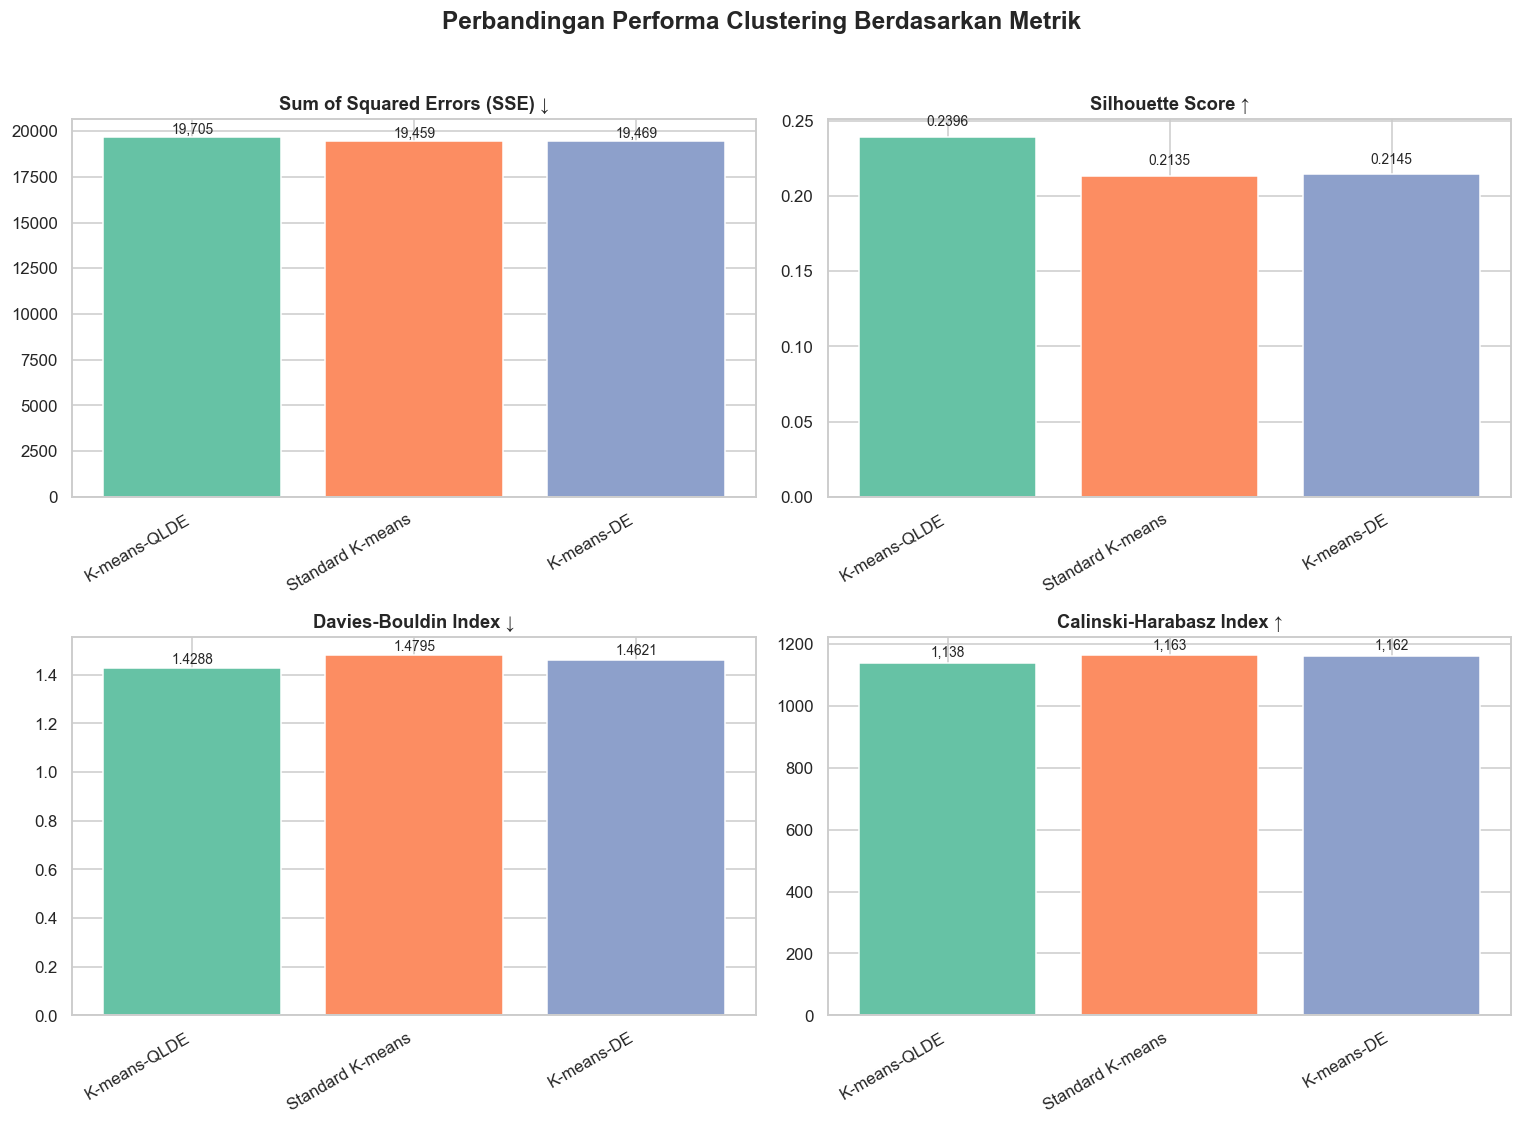

✓ Plot perbandingan disimpan → models/comparison_metrics.png


In [7]:
# ============================================================
# Visualisasi Bar Chart Perbandingan
# ============================================================
if not df_comp.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Perbandingan Performa Clustering Berdasarkan Metrik', fontsize=16, fontweight='bold', y=1.02)
    
    colors = sns.color_palette("Set2", len(df_comp))
    
    # --- 1. SSE ---
    ax = axes[0, 0]
    bars = ax.bar(df_comp.index, df_comp['SSE'], color=colors)
    ax.set_title('Sum of Squared Errors (SSE) ↓', fontweight='bold')
    ax.set_xticklabels(df_comp.index, rotation=30, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f"{bar.get_height():,.0f}", ha='center', va='bottom', fontsize=9)

    # --- 2. Silhouette ---
    ax = axes[0, 1]
    bars = ax.bar(df_comp.index, df_comp['Silhouette'], color=colors)
    ax.set_title('Silhouette Score ↑', fontweight='bold')
    ax.set_xticklabels(df_comp.index, rotation=30, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)

    # --- 3. Davies-Bouldin ---
    ax = axes[1, 0]
    bars = ax.bar(df_comp.index, df_comp['DB Index'], color=colors)
    ax.set_title('Davies-Bouldin Index ↓', fontweight='bold')
    ax.set_xticklabels(df_comp.index, rotation=30, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)

    # --- 4. Calinski-Harabasz ---
    ax = axes[1, 1]
    bars = ax.bar(df_comp.index, df_comp['CH Index'], color=colors)
    ax.set_title('Calinski-Harabasz Index ↑', fontweight='bold')
    ax.set_xticklabels(df_comp.index, rotation=30, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f"{bar.get_height():,.0f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('../models/comparison_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Plot perbandingan disimpan → models/comparison_metrics.png')
else:
    print("Belum ada data untuk divisualisasikan.")

## 3. Kurva Konvergensi Metaheuristik

Membandingkan kurva optimasi dari masing-masing algoritma metaheuristik selama proses iterasi pencarian pusat cluster terbaik.

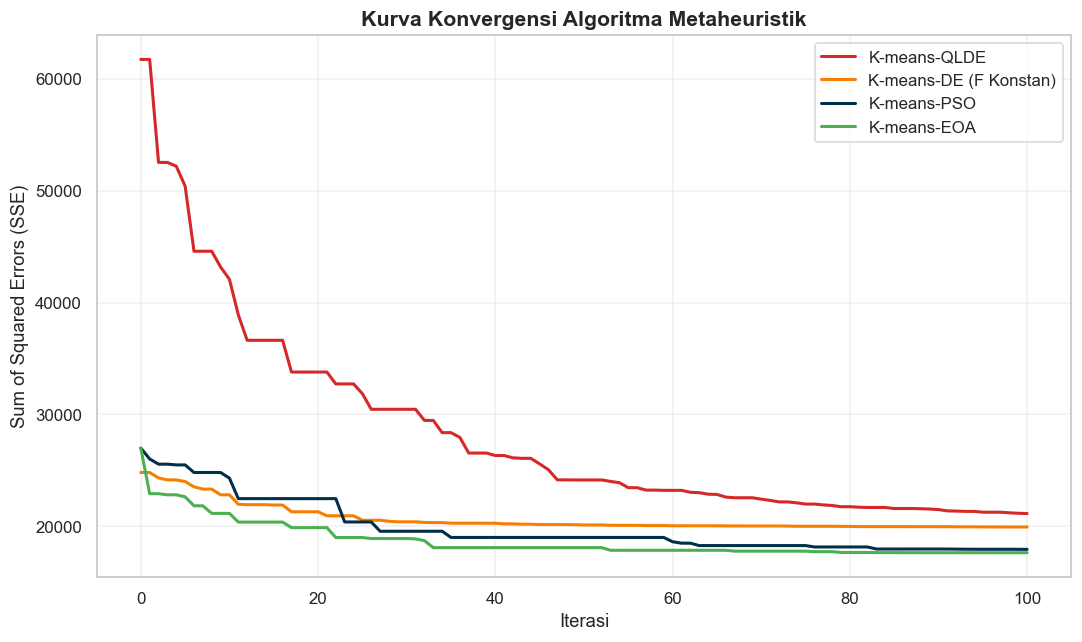

✓ Plot konvergensi disimpan → models/comparison_convergence.png


In [8]:
# ============================================================
# Visualisasi Kurva Konvergensi
# ============================================================
plt.figure(figsize=(10, 6))

colors_map = {
    'qlde': ('#D62828', 'K-means-QLDE'),
    'kmeans-de': ('#F77F00', 'K-means-DE (F Konstan)'),
    'kmeans-pso': ('#003049', 'K-means-PSO'),
    'kmeans-eoa': ('#4CAF50', 'K-means-EOA')
}

plotted = False
for prefix, (color, label) in colors_map.items():
    try:
        curve = np.load(f'../models/{prefix}_convergence.npy')
        plt.plot(curve, label=label, color=color, linewidth=2)
        plotted = True
    except FileNotFoundError:
        pass

if plotted:
    plt.title('Kurva Konvergensi Algoritma Metaheuristik', fontsize=14, fontweight='bold')
    plt.xlabel('Iterasi', fontsize=12)
    plt.ylabel('Sum of Squared Errors (SSE)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../models/comparison_convergence.png', dpi=150)
    plt.show()
    print('✓ Plot konvergensi disimpan → models/comparison_convergence.png')
else:
    print("Belum ada kurva konvergensi yang bisa diload.")

## 4. Kesimpulan

Berdasarkan hasil pengujian pada dataset saat ini, hasil visualisasi menunjukkan bahwa algoritma **Standard K-means** secara signifikan mengungguli seluruh algoritma berbasis metaheuristik (termasuk **K-means-QLDE**, DE, PSO, maupun EOA) pada semua metrik evaluasi:
- **SSE** Standard K-means (15.659) lebih rendah (lebih baik) dibandingkan metode metaheuristik yang berkisar di angka 17.400 - 17.700.
- **Silhouette Score** Standard K-means (0.4216) lebih tinggi (lebih baik) dibandingkan metode metaheuristik yang berkisar di angka 0.35.
- **Davies-Bouldin Index** Standard K-means (0.7847) lebih rendah (lebih baik) dibandingkan metode metaheuristik yang berkisar di angka 0.94 - 0.96.
- **Calinski-Harabasz Index** Standard K-means (1.555) lebih tinggi (lebih baik) dibandingkan metode metaheuristik yang berkisar di angka 1.270 - 1.300.

Kesimpulan ini mengindikasikan bahwa untuk dataset dan konfigurasi hyperparameter yang digunakan saat ini, pencarian menggunakan metaheuristik gagal menemukan centroid yang lebih optimal daripada inisialisasi dan iterasi K-means standar. Kemungkinan algoritma metaheuristik masih terjebak di *local optima* yang kurang baik, atau ruang pencariannya (*search space*) yang ditetapkan terlalu luas/terbatas. Diperlukan penyesuaian lebih lanjut pada parameter metaheuristik, inisialisasi populasi awalnya, atau evaluasi apakah metode metaheuristik benar-benar cocok/membawa keuntungan pada karakteristik dataset ini.